In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.dummy import DummyClassifier

# Models
lr   = joblib.load('../models/logreg_woe.pkl')
lgbm = joblib.load('../models/lgbm_model.pkl')

with open('../models/feature_names.json') as f:
    features = json.load(f)

# Data
train = pd.read_parquet('../data/processed/train_woe.parquet')
oot   = pd.read_parquet('../data/processed/oot_woe.parquet')

TARGET  = 'TARGET'
X_train = train[features]
y_train = train[TARGET]
X_oot   = oot[features]
y_oot   = oot[TARGET]

# Scores
train_scores = pd.read_parquet('../data/processed/train_scores.parquet')
oot_scores   = pd.read_parquet('../data/processed/oot_scores.parquet')

# Scorecard
scorecard = pd.read_csv('../models/scorecard_table.csv')

print("All artifacts loaded successfully")
print(f"Features in model: {len(features)}")

All artifacts loaded successfully
Features in model: 56


In [7]:
def ks_stat(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return round(max(tpr - fpr), 4)

def gini(y_true, y_prob):
    return round(2 * roc_auc_score(y_true, y_prob) - 1, 4)

def psi(expected, actual, bins=10):
    breakpoints  = np.unique(np.percentile(expected, np.linspace(0, 100, bins + 1)))
    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    exp_pct = np.where(exp_pct == 0, 1e-6, exp_pct)
    act_pct = np.where(act_pct == 0, 1e-6, act_pct)
    return round(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)), 4)

# Predictions
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)

p_dummy_tr = dummy.predict_proba(X_train)[:, 1]
p_dummy_ot = dummy.predict_proba(X_oot)[:, 1]
p_lr_tr    = lr.predict_proba(X_train)[:, 1]
p_lr_ot    = lr.predict_proba(X_oot)[:, 1]
p_lgbm_tr  = lgbm.predict_proba(X_train)[:, 1]
p_lgbm_ot  = lgbm.predict_proba(X_oot)[:, 1]

psi_score = psi(train_scores['score'].values, oot_scores['score'].values)

summary = pd.DataFrame([
    {
        'Model'      : 'DummyClassifier',
        'AUC Train'  : round(roc_auc_score(y_train, p_dummy_tr), 4),
        'AUC OOT'    : round(roc_auc_score(y_oot,   p_dummy_ot), 4),
        'KS Train'   : ks_stat(y_train, p_dummy_tr),
        'KS OOT'     : ks_stat(y_oot,   p_dummy_ot),
        'Gini OOT'   : gini(y_oot, p_dummy_ot),
        'PSI'        : '—',
    },
    {
        'Model'      : 'Logistic Regression (WoE)',
        'AUC Train'  : round(roc_auc_score(y_train, p_lr_tr), 4),
        'AUC OOT'    : round(roc_auc_score(y_oot,   p_lr_ot), 4),
        'KS Train'   : ks_stat(y_train, p_lr_tr),
        'KS OOT'     : ks_stat(y_oot,   p_lr_ot),
        'Gini OOT'   : gini(y_oot, p_lr_ot),
        'PSI'        : psi_score,
    },
    {
        'Model'      : 'LightGBM',
        'AUC Train'  : round(roc_auc_score(y_train, p_lgbm_tr), 4),
        'AUC OOT'    : round(roc_auc_score(y_oot,   p_lgbm_ot), 4),
        'KS Train'   : ks_stat(y_train, p_lgbm_tr),
        'KS OOT'     : ks_stat(y_oot,   p_lgbm_ot),
        'Gini OOT'   : gini(y_oot, p_lgbm_ot),
        'PSI'        : '—',
    },
]).set_index('Model')

print(summary.to_string())

                           AUC Train  AUC OOT  KS Train  KS OOT  Gini OOT     PSI
Model                                                                            
DummyClassifier               0.5000   0.5016    0.0000  0.0032    0.0032       —
Logistic Regression (WoE)     0.7625   0.7619    0.3952  0.3985    0.5238  0.0001
LightGBM                      0.8247   0.7715    0.4948  0.4086    0.5430       —


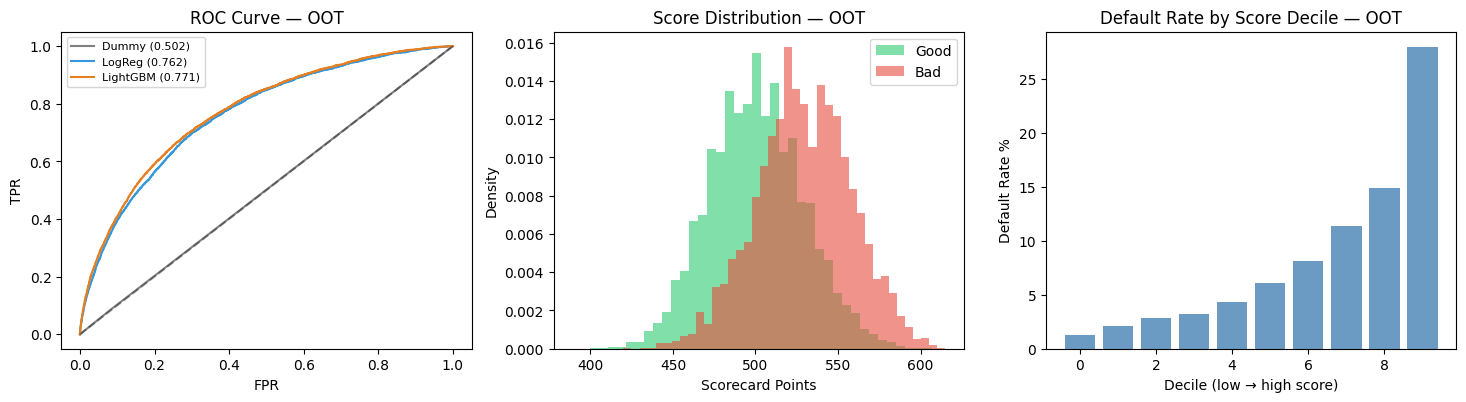

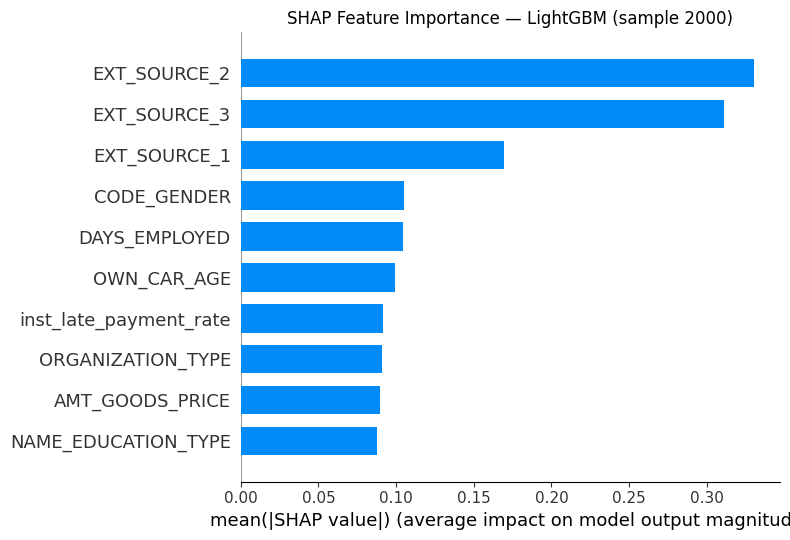

<Figure size 640x480 with 0 Axes>

Saved: models/final_dashboard.png


In [8]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig)

# --- ROC Curves ---
ax1 = fig.add_subplot(gs[0, 0])
for probs, name, color in [
    (p_dummy_ot, 'Dummy',    'gray'),
    (p_lr_ot,    'LogReg',   '#3498db'),
    (p_lgbm_ot,  'LightGBM', '#e67e22'),
]:
    fpr, tpr, _ = roc_curve(y_oot, probs)
    auc = roc_auc_score(y_oot, probs)
    ax1.plot(fpr, tpr, label=f'{name} ({auc:.3f})', color=color)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_title('ROC Curve — OOT')
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR')
ax1.legend(fontsize=8)

# --- Score Distribution ---
ax2 = fig.add_subplot(gs[0, 1])
for target, color, name in [(0, '#2ecc71', 'Good'), (1, '#e74c3c', 'Bad')]:
    mask = oot_scores['target'] == target
    ax2.hist(oot_scores.loc[mask, 'score'], bins=40,
             alpha=0.6, color=color, label=name, density=True)
ax2.set_title('Score Distribution — OOT')
ax2.set_xlabel('Scorecard Points')
ax2.set_ylabel('Density')
ax2.legend()

# --- Default Rate by Score Decile ---
ax3 = fig.add_subplot(gs[0, 2])
score_df = oot_scores.copy()
score_df['decile'] = pd.qcut(score_df['score'], q=10, duplicates='drop', labels=False)
dr = score_df.groupby('decile')['target'].mean() * 100
ax3.bar(dr.index, dr.values, color='steelblue', alpha=0.8)
ax3.set_title('Default Rate by Score Decile — OOT')
ax3.set_xlabel('Decile (low → high score)')
ax3.set_ylabel('Default Rate %')

# --- SHAP Summary (отдельный график) ---
shap_sample = X_train.sample(2000, random_state=42)
shap_values = shap.TreeExplainer(lgbm).shap_values(shap_sample)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, shap_sample,
                  plot_type='bar', max_display=10, show=False)
plt.title('SHAP Feature Importance — LightGBM (sample 2000)')
plt.tight_layout()
plt.savefig('../models/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
# --- Scorecard Top Features ---
ax5 = fig.add_subplot(gs[1, 2])
top_sc = (scorecard.groupby('Feature')['Points']
          .apply(lambda x: x.max() - x.min())
          .sort_values(ascending=False)
          .head(10))
ax5.barh(top_sc.index, top_sc.values, color='#9b59b6', alpha=0.8)
ax5.set_title('Scorecard — Point Range by Feature')
ax5.set_xlabel('Max - Min Points')
ax5.invert_yaxis()

# --- PSI Bar ---
ax6 = fig.add_subplot(gs[2, 0])
bins_n = 10
bp = np.unique(np.percentile(train_scores['score'], np.linspace(0, 100, bins_n + 1)))
exp_pct = np.histogram(train_scores['score'], bins=bp)[0] / len(train_scores)
act_pct = np.histogram(oot_scores['score'],   bins=bp)[0] / len(oot_scores)
x = np.arange(len(exp_pct))
ax6.bar(x - 0.2, exp_pct, 0.4, label='Train', color='steelblue', alpha=0.7)
ax6.bar(x + 0.2, act_pct, 0.4, label='OOT',   color='orange',    alpha=0.7)
ax6.set_title(f'Score PSI = {psi_score}')
ax6.set_xlabel('Score Bin')
ax6.set_ylabel('% Population')
ax6.legend()

# --- Metrics Bar Chart ---
ax7 = fig.add_subplot(gs[2, 1:])
metrics = ['AUC OOT', 'KS OOT', 'Gini OOT']
models  = ['Logistic Regression (WoE)', 'LightGBM']
x       = np.arange(len(metrics))
width   = 0.3

for i, model in enumerate(models):
    vals = [float(summary.loc[model, m]) for m in metrics]
    ax7.bar(x + i * width, vals, width, label=model, alpha=0.8)

ax7.set_xticks(x + width / 2)
ax7.set_xticklabels(metrics)
ax7.set_title('Model Performance Comparison — OOT')
ax7.set_ylabel('Score')
ax7.legend()
ax7.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='AUC=0.70 threshold')

plt.suptitle('Home Credit Default Risk — Final Model Dashboard', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../models/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: models/final_dashboard.png")

In [9]:
# Демонстрация как модель работает на одном клиенте
sample = X_oot.iloc[[0]]
true_label = y_oot.iloc[0]

lr_prob   = lr.predict_proba(sample)[0][1]
lgbm_prob = lgbm.predict_proba(sample)[0][1]
score     = oot_scores.iloc[0]['score']

print("=" * 50)
print("SINGLE CLIENT SCORING EXAMPLE")
print("=" * 50)
print(f"True label           : {'DEFAULT' if true_label == 1 else 'NO DEFAULT'}")
print(f"LR probability       : {lr_prob:.4f} ({lr_prob*100:.1f}% default risk)")
print(f"LightGBM probability : {lgbm_prob:.4f} ({lgbm_prob*100:.1f}% default risk)")
print(f"Scorecard points     : {score}")

# Risk band
if score < 520:
    band, action = 'Very High', 'REJECT'
elif score < 560:
    band, action = 'High', 'MANUAL REVIEW'
elif score < 600:
    band, action = 'Medium', 'CONDITIONAL APPROVE'
elif score < 640:
    band, action = 'Low', 'APPROVE'
else:
    band, action = 'Very Low', 'APPROVE + BEST RATE'

print(f"Risk band            : {band}")
print(f"Recommended action   : {action}")

SINGLE CLIENT SCORING EXAMPLE
True label           : NO DEFAULT
LR probability       : 0.4285 (42.9% default risk)
LightGBM probability : 0.4415 (44.2% default risk)
Scorecard points     : 507
Risk band            : Very High
Recommended action   : REJECT


# Home Credit Default Risk — Project Summary

## Business Problem
Predict probability of loan default for retail banking clients using 
historical credit data. Output: probability score + interpretable 
points-based scorecard for credit officers.

## Data
- **Source:** Home Credit Default Risk (Kaggle)
- **Main table:** 307,511 applicants, 122 features
- **Additional tables:** 6 (bureau, previous applications, 
  installments, credit card, POS cash)
- **Target:** 8% default rate (highly imbalanced)

## Methodology
| Step | Method | Result |
|---|---|---|
| EDA | Distribution analysis, Mann-Whitney, Chi-Square | 16/16 categorical features significant |
| Feature Engineering | Join 7 tables, aggregations | [вставь N] features |
| Feature Selection | IV (≥ 0.02) + Correlation (< 0.85) | [вставь N] features |
| WoE Encoding | OptimalBinning | Monotonic risk encoding |
| Modelling | LogReg + LightGBM | AUC OOT = [вставь] |
| Scorecard | PDO=20, Base=600 | [вставь score range] points |
| Validation | KS, Gini, PSI, Calibration | PSI = [вставь] ✅ |

## Final Results
| Model | AUC OOT | KS OOT | Gini OOT | PSI |
|---|---|---|---|---|
| DummyClassifier | ~0.50 | ~0.00 | ~0.00 | — |
| Logistic Regression | [вставь] | [вставь] | [вставь] | [вставь] |
| LightGBM | [вставь] | [вставь] | [вставь] | — |

## Key Findings
1. **EXT_SOURCE_1/2/3** — external credit bureau scores are the 
   strongest predictors (IV > 0.15)
2. **DAYS_EMPLOYED** — employment duration strongly discriminates 
   risk segments
3. **inst_late_payment_rate** — installment payment behavior from 
   historical data adds significant predictive power
4. **Scorecard** is stable across Train→OOT (PSI < 0.1), 
   confirming production readiness

## Production Readiness
- Model exported: `models/logreg_woe.pkl`
- Binning process exported: `models/binning_process.pkl`  
- Scorecard table: `models/scorecard_table.csv`
- API demo: `app/app.py` (Streamlit)

## Industry Benchmark Comparison
| Metric | This Model | Industry Minimum | Status |
|---|---|---|---|
| AUC | [вставь] | 0.65 | ✅ |
| KS  | [вставь] | 0.20 | ✅ |
| Gini| [вставь] | 0.30 | ✅ |
| PSI | [вставь] | < 0.10 | ✅ |